In [1]:
import numpy as np
import pandas as pd
import re

import warnings
warnings.filterwarnings('ignore')

In [2]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [3]:
folder_path = '/content/drive/MyDrive/Colab Notebooks/finalPJT/data/'

In [4]:
## Essence_dataset 불러오기 ##
essence_raw = pd.read_csv(folder_path+'Essence_dataset.csv')
essence_df = essence_raw.copy()
print(essence_df.shape)
essence_df.head(2)

(360, 10)


,name,brand,price,sale_price,picture,url,volume,skin_type,ingredient,review
0,[아랑Pick] VT 리들샷 100 에센스 50ml 기획/단품,VT,"32,000","24,600",https://image.oliveyoung.co.kr/uploads/images/...,https://www.oliveyoung.co.kr/store/goods/getGo...,50ml,모든피부 타입,"정제수, 다이프로필렌글라이콜, 글리세린, 나이아신아마이드, 부틸렌글라이콜, 마카다미...","[""얇고 민감한 제 피부엔 100도 엄청 따갑고 자극적이게 느꺼졌어요ㅜ 자주 사용하..."
1,[심톨Pick] 이니스프리 레티놀 피디알엔 스킨부스터 앰플 25ml (+25ml),이니스프리,"40,000","30,400",https://image.oliveyoung.co.kr/uploads/images/...,https://www.oliveyoung.co.kr/store/goods/getGo...,25mL 외,모든 피부,"락토바실러스발효용해물(56.88%), 글리세린, 프로판다이올, 정제수, 다이프로필렌...","[""시카 흔적 세럼보다 색이 더 노랗고 조금 더 쫀쫀해요 흰통같은 경우에는 지성분들..."


1. 제품 전처리
    * 기획 상품 or 묶음 상품에 대한 처리 O
1. price의 데이터 타입 변경 O
2. price에 있는 null값을 sale_price로 채우기 O
3. review 데이터를 텍스트 데이터 전처리를 위해 [] 없애고 string으로 만들어주기 O
7. skin_type 전처리 O
4. 리뷰 길이 확인하기 O
    * string으로 바꾼 문장의 길이 확인
    * 제품별 리스트 안의 리뷰 길이 평균 확인
9. review 데이터 전처리 -ing
    * 오타 처리
    * 불용어 처리
6. 성분 전처리
8. volume 전처리



## 제품 전처리

In [24]:
# 이름이 같은 거 우선 중복 제거
essence_df = essence_df.drop_duplicates(subset='name', keep='first').reset_index(drop=True)
print(essence_df.shape)

(352, 11)


In [25]:
# 상품명을 정제하는 함수 정의
def clean_product_name(name, brand):
    # 영어는 모두 소문자로 변환한다.
    name = name.lower()
    # 대괄호 및 대괄호 내 텍스트 제거
    name = re.sub(r'\[.*?\]', '', name)
    # 소괄호 및 소괄호 내 텍스트 제거
    name = re.sub(r'\(.*?\)', '', name)
    # 숫자 +g 또는 숫자 +ml 패턴 제거
    name = re.sub(r'\d+(ml|g)', '', name)

    # 기획 상품 단어 제거
    set_product_words = ['듀오기획', '트리오', '기획', '2입', '콜라보', '더블', '단독', '세트',
                         '증정', '단품', '대용량', '리필형', '리필', '한정']
    for word in set_product_words:
        name = name.replace(word, '')

    # + 기호와 + 기호 앞뒤 텍스트 제거
    name = re.sub(r'\d+\+\d+', '', name) # 패턴 제거
    name = re.sub(r'\+', '', name) # 남아있는 + 기호 제거

    # 특수 문자 제거
    name = re.sub(r'[^가-힣a-zA-Z0-9\s]', '', name) # 모든 특수 문자 및 기호 제거

    # 공백 제거
    name = re.sub(r'\s+', ' ', name).strip() # 제품명 앞 뒤 공백 제거
    name = re.sub(r'\s+', '', name) # 제품 사이의 공백 제거

    return name

In [26]:
## name 컬럼 정제하기 ##
essence_df['cleaned_name'] = \
essence_df.apply(lambda row : clean_product_name(row['name'], row['brand'].lower()), axis=1)

In [27]:
essence_df.head(1)

,name,brand,price,sale_price,picture,url,volume,skin_type,ingredient,review,cleaned_name
0,[아랑Pick] VT 리들샷 100 에센스 50ml 기획/단품,VT,"32,000","24,600",https://image.oliveyoung.co.kr/uploads/images/...,https://www.oliveyoung.co.kr/store/goods/getGo...,50ml,모든피부 타입,"정제수, 다이프로필렌글라이콜, 글리세린, 나이아신아마이드, 부틸렌글라이콜, 마카다미...","[""얇고 민감한 제 피부엔 100도 엄청 따갑고 자극적이게 느꺼졌어요ㅜ 자주 사용하...",vt리들샷100에센스


In [28]:
## cleaned_name을 브랜드별로 묶어서 확인하기 ##
# 조회 컬럼 선별하기
columns = ['name', 'cleaned_name', 'brand', 'price', 'ingredient', 'review']
temp = essence_df[columns]

# 결과 출력
grouped = temp.groupby(['brand'])

# 조회
for brand, group in grouped:
    print(f'브랜드 : {brand}')
    display(group)
    print('\n')

브랜드 : ('AHC',)


,name,cleaned_name,brand,price,ingredient,review
55,AHC 프로 샷 콜라 쥬비네이션 리프팅 세럼 40ml 기획 (+아이크림 10ml),ahc프로샷콜라쥬비네이션리프팅세럼,AHC,"60,000","[본품 - AHC 프로샷 콜라쥬비네이션 리프팅 세럼]\n정제수, 글리세린, 프로판다...","[""30대고 얇은 피부를 가지고 있어요 아이크림은 눈가와 팔자주름에 발라주고 세럼은..."
73,[올리브영단독] AHC 365 레드세럼 시너지 기획,ahc365레드세럼시너지,AHC,"32,000","히비스커스꽃추출물, 글리세린, 녹차수, 비피다발효용해물, 프로판다이올, 나이아신아마...","[""향도 강하지 않고 금방 흡수되어서 좋아요 발림성도 좋고요 적당히 보습되어서 좋습..."
152,AHC 에이치 멜라루트 앰플 스페셜 기획 (앰플10ml*2+크림20ml+앰플4.5m...,ahc에이치멜라루트앰플스페셜,AHC,"33,000","참당귀뿌리추출물, 글리세린, 나이아신아마이드, 카프릴릭/카프릭트라이글리세라이드, 비...","[""미백제품임에도 자극적이지 않고 비교적 순해서 사용하기 좋았어요. 묽은 제형으로 ..."




브랜드 : ('CKD',)


,name,cleaned_name,brand,price,ingredient,review
95,CKD 레티노콜라겐 저분자 300 콜라겐 펌핑 앰플 30ml,ckd레티노콜라겐저분자300콜라겐펌핑앰플,CKD,"34,000","정제수, 글리세린, 부틸렌글라이콜, 프로판다이올, 베타인, 카프릴릭/카프릭트라이글리...","[""용기가너무불편해요ㅜㅜ제형은흐르는제형이에요 저는그냥그랬네요'"", ""탄력 향상은 아..."
110,[한혜진PICK]CKD 레티노콜라겐 저분자 300 괄사 리프팅 세럼 30ml 1+1기획,ckd레티노콜라겐저분자300괄사리프팅세럼,CKD,NaN,"하이드롤라이즈드콜라겐추출물(71.73%), 글리세린, 프로판다이올, 정제수, 펜틸렌...","[""열흘정도 써봤는데 아직은 드라마틱한 느낌은 없지만 자극없고 마사지 느낌이 들어 ..."
306,[단독기획/1+1] CKD 레티노콜라겐 저분자 300 퍼스트에센스 1+1 기획,ckd레티노콜라겐저분자300퍼스트에센스,CKD,NaN,"클루이베르마이세스추출물(83.05%), 하이드롤라이즈드콜라겐\n추출물(50,600p...","[""완전완전 좋아요 건성에 진짜 좋은거같아요 토너 다음에 사용하면 좋을거같아요'"",..."




브랜드 : ('SNP',)


...

,name,cleaned_name,brand,price,ingredient,review
183,허스텔러 리틀 드롭스 카밍 데이즈 앰플 30ml 기획,허스텔러리틀드롭스카밍데이즈앰플,허스텔러,"34,000","포트마리골드꽃추출물, 부틸렌글라이콜, 카프릴릭/카프릭트라이글리세라이드, 에탄올, 글...","[""허스텔러 앰플은 벌써 몇통을 비운 제품이에요 허스텔러 브랜드 제품은 다 순해서 ..."




브랜드 : ('헤이네이처',)


,name,cleaned_name,brand,price,ingredient,review
191,헤이네이처 어성초 앰플 20ml 기획(+어성초 마스크 2매),헤이네이처어성초앰플,헤이네이처,NaN,"[ 어성초앰플 20ml(산뜻) ]\n정제수, 약모밀추출물(20%), 부틸렌글라이콜,...","[""별써 몇통째 사용중인지... 토너사용후 바로 사용하는데 산뜻하게 흡수되는데 아주..."




브랜드 : ('후시다인',)


,name,cleaned_name,brand,price,ingredient,review
214,후시다인 더마 트러블 밸런싱 세럼 40g,후시다인더마트러블밸런싱세럼,후시다인,"35,000","정제수, 글리세린, 부틸렌글라이콜, 프로판다이올, 푸시디움 코키네움발효용해추출여과물...","[""굉장히 순하고 지성인 저랑 잘 맞아서 쓰고 있어요 추천합니다'"", ""촉촉하고 피..."


In [29]:
## 제거해야 할 인덱스
remove_index = [296, 37, 346, 349, 252, 240, 249, 267, 329, 337, 247, 331, 246, 339, 320, 328, 168, 345, 77, 136, 350, 40, 276, 321, 295, 76, 59, 332, 342, 159,
                325, 12, 226, 287, 172, 243, 105, 185, 218, 46, 221, 69, 298, 60, 227, 284, 211, 44, 302, 210, 195, 20, 311, 286, 257, 271, 272, 207, 138, 293,
                23, 11, 36, 248, 103, 264, 351, 170, 24, 9, 274, 275, 278, 283, 215, 58, 29, 344, 43, 8, 42, 4, 39, 203, 245, 179]

# remove_index 제거
essence = essence_df.drop(index=remove_index).reset_index(drop=True)
# cleaned_name 제거
essence = essence.drop(columns='cleaned_name')
print(essence.shape)
essence.head(2)

(266, 10)


,name,brand,price,sale_price,picture,url,volume,skin_type,ingredient,review
0,[아랑Pick] VT 리들샷 100 에센스 50ml 기획/단품,VT,"32,000","24,600",https://image.oliveyoung.co.kr/uploads/images/...,https://www.oliveyoung.co.kr/store/goods/getGo...,50ml,모든피부 타입,"정제수, 다이프로필렌글라이콜, 글리세린, 나이아신아마이드, 부틸렌글라이콜, 마카다미...","[""얇고 민감한 제 피부엔 100도 엄청 따갑고 자극적이게 느꺼졌어요ㅜ 자주 사용하..."
1,[심톨Pick] 이니스프리 레티놀 피디알엔 스킨부스터 앰플 25ml (+25ml),이니스프리,"40,000","30,400",https://image.oliveyoung.co.kr/uploads/images/...,https://www.oliveyoung.co.kr/store/goods/getGo...,25mL 외,모든 피부,"락토바실러스발효용해물(56.88%), 글리세린, 프로판다이올, 정제수, 다이프로필렌...","[""시카 흔적 세럼보다 색이 더 노랗고 조금 더 쫀쫀해요 흰통같은 경우에는 지성분들..."


In [30]:
essence.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 266 entries, 0 to 265
Data columns (total 10 columns):
 #   Column      Non-Null Count  Dtype 
---  ------      --------------  ----- 
 0   name        266 non-null    object
 1   brand       266 non-null    object
 2   price       171 non-null    object
 3   sale_price  266 non-null    object
 4   picture     266 non-null    object
 5   url         266 non-null    object
 6   volume      266 non-null    object
 7   skin_type   266 non-null    object
 8   ingredient  266 non-null    object
 9   review      266 non-null    object
dtypes: object(10)
memory usage: 20.9+ KB


## Price 전처리

In [31]:
## 데이터 타입 변경 : float ##
essence.price = essence.price.str.replace(',', '').astype('float')
essence.sale_price = essence.sale_price.str.replace(',', '').astype('float')

In [32]:
essence.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 266 entries, 0 to 265
Data columns (total 10 columns):
 #   Column      Non-Null Count  Dtype  
---  ------      --------------  -----  
 0   name        266 non-null    object 
 1   brand       266 non-null    object 
 2   price       171 non-null    float64
 3   sale_price  266 non-null    float64
 4   picture     266 non-null    object 
 5   url         266 non-null    object 
 6   volume      266 non-null    object 
 7   skin_type   266 non-null    object 
 8   ingredient  266 non-null    object 
 9   review      266 non-null    object 
dtypes: float64(2), object(8)
memory usage: 20.9+ KB


In [33]:
## price가 null인 인덱스 저장
price_null_index = essence[essence.price.isnull()].index
price_null_index

Index([ 10,  17,  20,  29,  30,  31,  37,  42,  43,  44,  45,  46,  47,  48,
        50,  51,  53,  54,  56,  57,  58,  62,  63,  64,  65,  71,  73,  77,
        85,  87,  89,  90,  91,  93,  94,  95,  96,  97, 103, 104, 105, 110,
       111, 112, 113, 114, 116, 117, 118, 123, 124, 126, 127, 128, 129, 131,
       132, 135, 136, 140, 145, 146, 147, 148, 149, 155, 156, 157, 158, 163,
       164, 167, 177, 178, 197, 201, 204, 206, 209, 210, 213, 221, 236, 237,
       238, 239, 242, 243, 244, 251, 253, 256, 259, 260, 261],
      dtype='int64')

In [34]:
# price의 null 값을 같은 행의 sale_price로 채우기
for idx in price_null_index:
    essence.loc[idx, 'price'] = essence.loc[idx, 'sale_price']

In [35]:
essence.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 266 entries, 0 to 265
Data columns (total 10 columns):
 #   Column      Non-Null Count  Dtype  
---  ------      --------------  -----  
 0   name        266 non-null    object 
 1   brand       266 non-null    object 
 2   price       266 non-null    float64
 3   sale_price  266 non-null    float64
 4   picture     266 non-null    object 
 5   url         266 non-null    object 
 6   volume      266 non-null    object 
 7   skin_type   266 non-null    object 
 8   ingredient  266 non-null    object 
 9   review      266 non-null    object 
dtypes: float64(2), object(8)
memory usage: 20.9+ KB


## Review 전처리 1

In [36]:
## 리뷰 []에서 분리하고 리뷰를 하나의 string으로 만들어 주는 함수 ##
def split_reviews(raw):
    df = raw.copy()
    # string 타입으로 넣어줄 컬럼 생성
    df['all_reviews'] = None
    # df 개수 만큼 돌려가며 리뷰를 전처리하기
    for n in range(df.shape[0]):
        reviews = ''

        # review의 []를 제거하고 ", "를 기준으로 80개의 문장 분리하기
        df.review[n] = df.review[n][2:-2].split('", "')

        # 위에서 나눈 review (list)의 길이 만큼 돌면서 string 만들어주기
        for i in range(len(df.review[n])):
            df.review[n][i] = df.review[n][i].strip("'")
            reviews = reviews + df.review[n][i] + ' '

        df['all_reviews'][n] = reviews

    return df

In [37]:
# 리뷰의 리스트 벗기고 string으로 만들어주기
essence = split_reviews(essence)
print(essence.shape)
essence.head(2)

(266, 11)


,name,brand,price,sale_price,picture,url,volume,skin_type,ingredient,review,all_reviews
0,[아랑Pick] VT 리들샷 100 에센스 50ml 기획/단품,VT,32000.0,24600.0,https://image.oliveyoung.co.kr/uploads/images/...,https://www.oliveyoung.co.kr/store/goods/getGo...,50ml,모든피부 타입,"정제수, 다이프로필렌글라이콜, 글리세린, 나이아신아마이드, 부틸렌글라이콜, 마카다미...",[얇고 민감한 제 피부엔 100도 엄청 따갑고 자극적이게 느꺼졌어요ㅜ 자주 사용하기...,얇고 민감한 제 피부엔 100도 엄청 따갑고 자극적이게 느꺼졌어요ㅜ 자주 사용하기엔...
1,[심톨Pick] 이니스프리 레티놀 피디알엔 스킨부스터 앰플 25ml (+25ml),이니스프리,40000.0,30400.0,https://image.oliveyoung.co.kr/uploads/images/...,https://www.oliveyoung.co.kr/store/goods/getGo...,25mL 외,모든 피부,"락토바실러스발효용해물(56.88%), 글리세린, 프로판다이올, 정제수, 다이프로필렌...",[시카 흔적 세럼보다 색이 더 노랗고 조금 더 쫀쫀해요 흰통같은 경우에는 지성분들이...,시카 흔적 세럼보다 색이 더 노랗고 조금 더 쫀쫀해요 흰통같은 경우에는 지성분들이 ...


## skin_type 전처리

In [38]:
print(essence.skin_type.nunique())
essence.skin_type.unique()

44


array(['모든피부 타입', '모든 피부', '모든 피부 용', '모든 피부 타입', '모든 피부용',
       '모든 피부용 (민감피부도 사용가능)', '모든 피부타입용', '모든피부용', '■ 모든 피부용', '모든피부타입',
       '모든 피부 타입용', '모든피부', '지성,복합성피부, 모든피부', '모든피부용도', '모든 피부타입',
       '모든 피부타입/ 건성 피부', '민감한 피부타입', '모든 피부 사용가능', '■ 모든 피부 타입용',
       '수분 부족, 건성 피부 및 모든 피부', '모든 피부 사용',
       '5중 히알루론산과 세라마이드로 속보습부터 피부 탄력까지 채우며, 가벼운 제형으로 재탄생한 디오디너리 대표 수분 세럼',
       '모든피부용.', '모든 피부 (민감피부도 사용가능)', '■모든 피부 타입', '모든 피부용 / 반투명한 백색액상',
       '모든 타입', '무색, 무향', '지복합성 피부/ 트러블 피부', '모든피부 사용가능',
       '10% 나이아신아마이드 성분으로 피부톤과 모공을 한 번에 케어하는 미모 부스터',
       '모공을 막지 않는 동그라미 히알루론산™이 모공에 쏙! 들어가 층층이 보습을 쌓아 탄력은 올리고 모공은 쪼이고!',
       '민감성 및 지성/트러블 피부에 사용 적합', '모든 피부에 사용', '민감성 피부 및 모든 피부에 사용 적합',
       '모든 피부.', '모든피부용(페이스용)', '미황색', '모든 피부용 (민감 피부 사용 가능)',
       '모든 피부(민감피부도 사용 가능)',
       '레티놀 4X 1%가 탄력을 촘촘히 쌓아올려 매끈탱탱한 탄성 피부로 가꿔주는 데일리 레티놀 세럼',
       '민감성 및 모든 피부에 사용 적합', '모든 피부용(민감피부 사용가능)',
       '모공+다크스팟+피지+피부결 4중 케어 데일리 세럼 #4가지고민해결 #한번에피부리셋 #해결세럼'],
      dtype=object)

In [39]:
essence[essence.skin_type == '레티놀 4X 1%가 탄력을 촘촘히 쌓아올려 매끈탱탱한 탄성 피부로 가꿔주는 데일리 레티놀 세럼']

,name,brand,price,sale_price,picture,url,volume,skin_type,ingredient,review,all_reviews
251,[한정기획] 아이오페 레티놀 슈퍼 바운스 세럼 30ml+20ml 기획(+스템3크림 ...,아이오페,50000.0,50000.0,https://image.oliveyoung.co.kr/uploads/images/...,https://www.oliveyoung.co.kr/store/goods/getGo...,30ml,레티놀 4X 1%가 탄력을 촘촘히 쌓아올려 매끈탱탱한 탄성 피부로 가꿔주는 데일리 ...,정제수@부틸렌글라이콜@스쿠알란@메틸트라이메티콘@글리세린@비스-하이드록시에톡시프로필다...,"[자극없이 순하고 사용감이 너무 좋아요. 잘 사용하고 있어요., 오특에 올라 와서 ...",자극없이 순하고 사용감이 너무 좋아요. 잘 사용하고 있어요. 오특에 올라 와서 샀는...


In [40]:
# skin_type에 있는 특수 기호 변경
essence.skin_type = essence.skin_type.str.replace('(■|#|/)', '').str.strip()

## Review 길이 확인

In [41]:
## all_reviews 길이 확인하기
essence.all_reviews.apply(len).values.mean()

6701.206766917293

In [42]:
## 제품별 review 하나당 길이 확인
mean_list = []

for i in range(essence.shape[0]):
    reviews_length_mean = sum([len(review) for review in essence.review[i]]) / len(essence.review[i])
    mean_list.append(reviews_length_mean)

print('리뷰 한 개 당 평균 길이 :', round(sum(mean_list) / len(mean_list)))

리뷰 한 개 당 평균 길이 : 84


## Review 전처리 2
* 정제
* 문장 토큰화
* 문장 감성분석
* 긍/부정 분류
* 긍정 특징 추출, 부정 특징 추출
* 벡터화

### review 정제

In [43]:
!pip install konlpy
!pip install mecab-python # mecab 사용 (in Colab)
!bash <(curl -s https://raw.githubusercontent.com/konlpy/konlpy/master/scripts/mecab.sh)

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 19.4/19.4 MB 72.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 488.6/488.6 kB 28.6 MB/s eta 0:00:00
  Preparing metadata (setup.py) ... done
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 581.7/581.7 kB 10.3 MB/s eta 0:00:00
  Created wheel for mecab-python: filename=mecab_python-1.0.0-py3-none-any.whl size=1230 sha256=3f5e01b21184a901cc61272b23a017ad256b17e7a81d8a12df552bcc64b898ac
  Stored in directory: /root/.cache/pip/wheels/ec/41/c8/ce8fb469be2547ce596c4000613806505dc54c296aae45da71
Successfully built mecab-python
Install mecab-ko
  % Total    % Received % Xferd  Average Speed   Time    Time     Time  Current
                                 Dload  Upload   Total   Spent    Left  Speed
  0     0    0     0    0     0      0      0 --:--:-- --:--:-- --:--:--     0
100 1381k  100 1381k    0     0  1466k      0 --:--:-- --:--:-- --:--:-- 2736k
mecab-0.996-ko-0.9.2/
mecab-0.996-ko-0.9.2/example/
mecab-0.996-ko-0.9.2/example/exam

In [25]:
# essence.all_reviews[0]

In [44]:
## 정규표현식 함수 ##
def apply_regular_expression(text):
    hangul = re.compile('[^ ㄱ-ㅣ 가-힣]') # 띄어쓰기 1개를 포함한 한글 추출
    result = hangul.sub('', text) # 위에서 설정한 한글 규칙을 text에 적용한다.

    pattern = '([ㄱ-ㅎㅏ-ㅣ]+)'  # 한글 자음, 모음 제거
    result = re.sub(pattern, '', result)

    return result

In [45]:
## 맞춤법 고치기 함수 ## --> replacements 수정 필요
def fix_words(texts):
    replacements = {'랴':'려', '구용':'구요', '봣어요':'봤어요', '합니더':'합니다', '써봐성':'써봐서', '강추예영':'강추에요', '가봐용':'가봐요', '어용':'어요', '구여':'구요', '드랴여':'드려요',
                    '느꺼':'느껴', '네영':'네요', '겟':'겠', '니댜':'니다', '아파여':'아파요', '입니덩':'입니다'}

    cleaned_texts = apply_regular_expression(texts)

    for old, new in replacements.items():
        cleaned_texts = cleaned_texts.replace(old, new)

    return cleaned_texts

In [28]:
## cleaned_reviews 컬럼 새로 만들기
# essence['cleaned_reviews'] = essence.all_reviews.apply(fix_words)

### 토큰화
* 문장

In [46]:
## kss 설치 - KSS(Korean Sentence Splitter)
!pip install kss

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.1/1.1 MB 17.2 MB/s eta 0:00:00
  Preparing metadata (setup.py) ... done
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 26.4/26.4 MB 38.7 MB/s eta 0:00:00
  Preparing metadata (setup.py) ... done
  Preparing metadata (setup.py) ... done
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 180.3/180.3 kB 11.8 MB/s eta 0:00:00
  Preparing metadata (setup.py) ... done
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 131.3/131.3 kB 8.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 682.2/682.2 kB 28.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 939.4/939.4 kB 34.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 72.2/72.2 MB 8.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.6/1.6 MB 18.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 103.3/103.3 kB 5.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 235.5/235.5 kB 8.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━

In [47]:
import kss

In [48]:
## 문장 단위로 토큰화 진행 및 컬럼 설정 함수
def split_reviews(raw):
    df = raw.copy()

    # 빈 컬럼 생성
    df['cleaned_reviews'] = None

    # 맞춤법 고치기 함수 사용
    df['cleaned_reviews'] = df['all_reviews'].apply(fix_words)

    # 문장단위로 토큰화
    df['cleaned_reviews'] = df['cleaned_reviews'].apply(kss.split_sentences)

    return df

In [49]:
## cleaned_reviews를 문장 단위로 토큰화 우선 진행 ##
essence = split_reviews(essence)
essence.head(2)

,name,brand,price,sale_price,picture,url,volume,skin_type,ingredient,review,all_reviews,cleaned_reviews
0,[아랑Pick] VT 리들샷 100 에센스 50ml 기획/단품,VT,32000.0,24600.0,https://image.oliveyoung.co.kr/uploads/images/...,https://www.oliveyoung.co.kr/store/goods/getGo...,50ml,모든피부 타입,"정제수, 다이프로필렌글라이콜, 글리세린, 나이아신아마이드, 부틸렌글라이콜, 마카다미...",[얇고 민감한 제 피부엔 100도 엄청 따갑고 자극적이게 느꺼졌어요ㅜ 자주 사용하기...,얇고 민감한 제 피부엔 100도 엄청 따갑고 자극적이게 느꺼졌어요ㅜ 자주 사용하기엔...,"[얇고 민감한 제 피부엔 도 엄청 따갑고 자극적이게 느껴졌어요, 자주 사용하기엔 좀..."
1,[심톨Pick] 이니스프리 레티놀 피디알엔 스킨부스터 앰플 25ml (+25ml),이니스프리,40000.0,30400.0,https://image.oliveyoung.co.kr/uploads/images/...,https://www.oliveyoung.co.kr/store/goods/getGo...,25mL 외,모든 피부,"락토바실러스발효용해물(56.88%), 글리세린, 프로판다이올, 정제수, 다이프로필렌...",[시카 흔적 세럼보다 색이 더 노랗고 조금 더 쫀쫀해요 흰통같은 경우에는 지성분들이...,시카 흔적 세럼보다 색이 더 노랗고 조금 더 쫀쫀해요 흰통같은 경우에는 지성분들이 ...,"[시카 흔적 세럼보다 색이 더 노랗고 조금 더 쫀쫀해요, 흰통같은 경우에는 지성분들..."


In [75]:
essence.head()

,name,brand,price,sale_price,picture,url,volume,skin_type,ingredient,review,all_reviews,cleaned_reviews
0,[아랑Pick] VT 리들샷 100 에센스 50ml 기획/단품,VT,32000.0,24600.0,https://image.oliveyoung.co.kr/uploads/images/...,https://www.oliveyoung.co.kr/store/goods/getGo...,50ml,모든피부 타입,"정제수, 다이프로필렌글라이콜, 글리세린, 나이아신아마이드, 부틸렌글라이콜, 마카다미...",[얇고 민감한 제 피부엔 100도 엄청 따갑고 자극적이게 느꺼졌어요ㅜ 자주 사용하기...,얇고 민감한 제 피부엔 100도 엄청 따갑고 자극적이게 느꺼졌어요ㅜ 자주 사용하기엔...,"[얇고 민감한 제 피부엔 도 엄청 따갑고 자극적이게 느껴졌어요, 자주 사용하기엔 좀..."
1,[심톨Pick] 이니스프리 레티놀 피디알엔 스킨부스터 앰플 25ml (+25ml),이니스프리,40000.0,30400.0,https://image.oliveyoung.co.kr/uploads/images/...,https://www.oliveyoung.co.kr/store/goods/getGo...,25mL 외,모든 피부,"락토바실러스발효용해물(56.88%), 글리세린, 프로판다이올, 정제수, 다이프로필렌...",[시카 흔적 세럼보다 색이 더 노랗고 조금 더 쫀쫀해요 흰통같은 경우에는 지성분들이...,시카 흔적 세럼보다 색이 더 노랗고 조금 더 쫀쫀해요 흰통같은 경우에는 지성분들이 ...,"[시카 흔적 세럼보다 색이 더 노랗고 조금 더 쫀쫀해요, 흰통같은 경우에는 지성분들..."
2,이니스프리 레티놀 시카 흔적 앰플 30mL 기획 세트(+25ml+PDRN 5ml),이니스프리,40000.0,29200.0,https://image.oliveyoung.co.kr/uploads/images/...,https://www.oliveyoung.co.kr/store/goods/getGo...,레티놀 시카 흔적 앰플 30mL 기획 세트,모든 피부,"정제수, 글리세린, 부틸렌글라이콜, 나이아신아마이드, 다이부틸아디페이트, 카프릴릭/...",[많이 바르면 살짝 붉어지긴 하는데 양 조절해서 잘 바르면 좋은 것 같아요 이제 꾸...,많이 바르면 살짝 붉어지긴 하는데 양 조절해서 잘 바르면 좋은 것 같아요 이제 꾸준...,"[많이 바르면 살짝 붉어지긴 하는데 양 조절해서 잘 바르면 좋은 것 같아요, 이제 ..."
3,[모공세럼]넘버즈인 3번 보들보들 결 세럼 50ml 리필기획(50ml+50ml),넘버즈인,38000.0,27080.0,https://image.oliveyoung.co.kr/uploads/images/...,https://www.oliveyoung.co.kr/store/goods/getGo...,50ml+50ml,모든 피부 용,"비피다발효용해물, 갈락토미세스발효여과물, 부틸렌글라이콜, 메틸글루세스-20, 정제수...",[벌써 두통째 사용중 건조한 편인데 이거 바흐고 자면 다음날 광나는 피부+탱탱해진 ...,벌써 두통째 사용중 건조한 편인데 이거 바흐고 자면 다음날 광나는 피부+탱탱해진 느...,[벌써 두통째 사용중 건조한 편인데 이거 바흐고 자면 다음날 광나는 피부탱탱해진 느...
4,[7월 올영픽/아랑PICK] 파티온 노스카나인 트러블 세럼 단독 기획 (50ml+1...,파티온,38000.0,27900.0,https://image.oliveyoung.co.kr/uploads/images/...,https://www.oliveyoung.co.kr/store/goods/getGo...,50 ml+15 ml,모든 피부 타입,"쑥잎추출물, 정제수, 글리세린, 다이프로필렌글라이콜, 판테놀, 1,2-헥산다이올, ...",[파티온 클렌징워터 순해서 잘 쓰고 있었는데 트러블전용 세럼이 있길래 구매했어요 저...,파티온 클렌징워터 순해서 잘 쓰고 있었는데 트러블전용 세럼이 있길래 구매했어요 저는...,"[파티온 클렌징워터 순해서 잘 쓰고 있었는데 트러블전용 세럼이 있길래 구매했어요, ..."


In [50]:
## 제품별 리뷰를 각각의 행으로 분리하기
def explode_reviews(df):
    return df.explode('cleaned_reviews')[['name', 'cleaned_reviews']].reset_index(drop=True)

essence_review_prac1 = explode_reviews(essence)
print(essence_review_prac1.shape)
essence_review_prac1.tail(2)

(51404, 2)


,name,cleaned_reviews
51402,라로슈포제 멜라B3 세럼 30ml,발랐을때 좀따가웠고 바른후에 때처럼 밀려요 향도 개인적으로 불호에요 향이 첨가되어서...
51403,라로슈포제 멜라B3 세럼 30ml,벨벳처럼 마무리됩니다


In [51]:
# 나눠진 리뷰 길이 확인하기 - 최대길이 확인
essence_review_prac1.cleaned_reviews.apply(len)

0        33
1        53
2        11
3         8
4        16
         ..
51399    36
51400    33
51401    18
51402    63
51403    11
Name: cleaned_reviews, Length: 51404, dtype: int64

KoNLPy 라이브러리를 이용해서 형태소 분석 및 품사 태깅

(KoNLPy는 띄어쓰기 알고리즘과 정규화를 이용해서 맞춤법이 틀린 문장도 어느 정도 고쳐주면서 형태소 분석과 품사를 태깅해주는 여러 클래스를 제공합니다.)

In [52]:
from konlpy.tag import Mecab, Okt

In [58]:
# ## 예시 ##

# okt = Okt()
# mecab = Mecab()

# print(okt.pos(u'이 밤 그날의 반딧불을 당신의 창 가까이 보낼게요'))
# print(mecab.pos(u'이 밤 그날의 반딧불을 당신의 창 가까이 보낼게요'))

[('이', 'Noun'), ('밤', 'Noun'), ('그날', 'Noun'), ('의', 'Josa'), ('반딧불', 'Noun'), ('을', 'Josa'), ('당신', 'Noun'), ('의', 'Josa'), ('창', 'Noun'), ('가까이', 'Noun'), ('보낼게요', 'Verb')]
[('이', 'MM'), ('밤', 'NNG'), ('그날', 'NNG'), ('의', 'JKG'), ('반딧불', 'NNG'), ('을', 'JKO'), ('당신', 'NP'), ('의', 'JKG'), ('창', 'NNG'), ('가까이', 'MAG'), ('보낼', 'VV+ETM'), ('게요', 'NNB+VCP+EC')]


In [53]:
import nltk
nltk.download()

from nltk.corpus import stopwords

NLTK Downloader
---------------------------------------------------------------------------
    d) Download   l) List    u) Update   c) Config   h) Help   q) Quit
---------------------------------------------------------------------------
Downloader> d

Download which package (l=list; x=cancel)?
  Identifier> l
Packages:
  [ ] abc................. Australian Broadcasting Commission 2006
  [ ] alpino.............. Alpino Dutch Treebank
  [ ] averaged_perceptron_tagger Averaged Perceptron Tagger
  [ ] averaged_perceptron_tagger_eng Averaged Perceptron Tagger (JSON)
  [ ] averaged_perceptron_tagger_ru Averaged Perceptron Tagger (Russian)
  [ ] averaged_perceptron_tagger_rus Averaged Perceptron Tagger (Russian)
  [ ] basque_grammars..... Grammars for Basque
  [ ] bcp47............... BCP-47 Language Tags
  [ ] biocreative_ppi..... BioCreAtIvE (Critical Assessment of Information
                           Extraction Systems in Biology)
  [ ] bllip_wsj_no_aux.... BLLIP Parser: WSJ Model
  [ 

In [54]:
## 불용어 파일 가져오기
stopwords = pd.read_excel(folder_path+'stopword_list.xlsx')
# stopword 컬럼의 값들을 리스트화
stopwords = stopwords.stopword.tolist()

print(stopwords[-100:])

['것', '들', '그', '되', '수', '이', '보', '않', '없', '나', '사람', '주', '아니', '등', '같', '우리', '때', '년', '가', '한', '지', '대하', '오', '말', '일', '그렇', '위하', '때문', '그것', '두', '말하', '알', '그러나', '받', '못하', '일', '그런', '또', '문제', '더', '사회', '많', '그리고', '좋', '크', '따르', '중', '나오', '가지', '씨', '시키', '만들', '지금', '생각하', '그러', '속', '하나', '집', '살', '모르', '적', '월', '데', '자신', '안', '어떤', '내', '내', '경우', '명', '생각', '시간', '그녀', '다시', '이런', '앞', '보이', '번', '나', '다른', '어떻', '여자', '개', '전', '들', '사실', '이렇', '점', '싶', '말', '정도', '좀', '원', '잘', '통하', '놓', 'ㅎ', 'ㅎㅎ', 'ㅎㅎㅎ', 'ㅎㅎㅎㅎ']


In [42]:
# stopwords.remove('효과')
# len(stopwords)

2067

### prac1 리뷰 데이터에 예측 라벨링 해놓고 모델링 돌려보기
* 형태소 분리
* 정수 인코딩


In [55]:
## 형태소 분리하기
# mecab = Mecab()
okt = Okt()

def tokenized_review(text):
    text_morphs = okt.morphs(text, stem=True)
    morphs_list = [morph for morph in text_morphs if morph not in stopwords]
    return morphs_list

essence_review_prac1['tokenized_review'] = essence_review_prac1.cleaned_reviews.apply(tokenized_review)

essence_review_prac1.head(2)

,name,cleaned_reviews,tokenized_review
0,[아랑Pick] VT 리들샷 100 에센스 50ml 기획/단품,얇고 민감한 제 피부엔 도 엄청 따갑고 자극적이게 느껴졌어요,"[얇다, 민감하다, 피부, 엔, 도, 엄청, 따갑다, 자극, 게, 느껴지다]"
1,[아랑Pick] VT 리들샷 100 에센스 50ml 기획/단품,자주 사용하기엔 좀 그렇지만 가끔씩 써주면 좋은 제품 모델링팩 써준뒤에 사용하면 효...,"[자주, 가끔, 씩, 써주다, 좋다, 모델링, 팩, 써다, 뒤, 배]"


정수 인코딩

In [56]:
from tensorflow.keras.preprocessing.text import Tokenizer
from tensorflow.keras.preprocessing.sequence import pad_sequences

In [57]:
X = essence_review_prac1.tokenized_review.values

In [58]:
# 단어 집합 만들기
tokenizer = Tokenizer()

tokenizer.fit_on_texts(X)

In [59]:
threshold = 2
total_cnt = len(tokenizer.word_index) # 단어의 수
rare_cnt = 0 # 등장 빈도수가 threshold보다 작은 단어의 개수를 카운트
total_freq = 0 # 훈련 데이터의 전체 단어 빈도수 총 합
rare_freq = 0 # 등장 빈도수가 threshold보다 작은 단어의 등장 빈도수의 총 합

# 단어와 빈도수의 쌍(pair)을 key와 value로 받는다.
for key, value in tokenizer.word_counts.items():
    total_freq = total_freq + value

    # 단어의 등장 빈도수가 threshold보다 작으면
    if(value < threshold):
        rare_cnt = rare_cnt + 1
        rare_freq = rare_freq + value

print('단어 집합(vocabulary)의 크기 :',total_cnt)
print('등장 빈도가 %s번 이하인 희귀 단어의 수: %s'%(threshold - 1, rare_cnt))
print("단어 집합에서 희귀 단어의 비율:", (rare_cnt / total_cnt)*100)
print("전체 등장 빈도에서 희귀 단어 등장 빈도 비율:", (rare_freq / total_freq)*100)


단어 집합(vocabulary)의 크기 : 10844
등장 빈도가 1번 이하인 희귀 단어의 수: 4880
단어 집합에서 희귀 단어의 비율: 45.0018443378827
전체 등장 빈도에서 희귀 단어 등장 빈도 비율: 1.2968720933322704


In [60]:
# 전체 단어 개수 중 빈도수 2이하인 단어 개수는 제거.
# 0번 패딩 토큰과 1번 OOV 토큰을 고려하여 +2
vocab_size = total_cnt - rare_cnt + 2
print('단어 집합의 크기 :',vocab_size)

단어 집합의 크기 : 5966


In [61]:
# 단어 집합의 크기를 토크나이저의 인자로 넘겨주면, 토크나이저는 텍스트 시퀀스를 숫자 시퀀스로 변환
# 이러한 정수 인코딩 과정에서 이보다 큰 숫자가 부여된 단어들은 OOV로 변환

tokenizer = Tokenizer(vocab_size, oov_token = 'OOV')
tokenizer.fit_on_texts(X)
X = tokenizer.texts_to_sequences(X)

In [62]:
# 정수 인코딩 진행 확인
print(X[:3])

[[419, 188, 3, 93, 4, 75, 121, 13, 49, 45], [154, 374, 189, 429, 2, 765, 143, 11, 340, 1348], [44, 2]]


패딩 - 서로 다른 길이의 샘플들의 길이를 동일하게 맞춰주는 패딩 작업

리뷰의 최대 길이 : 171
리뷰의 평균 길이 : 7.32024745156019


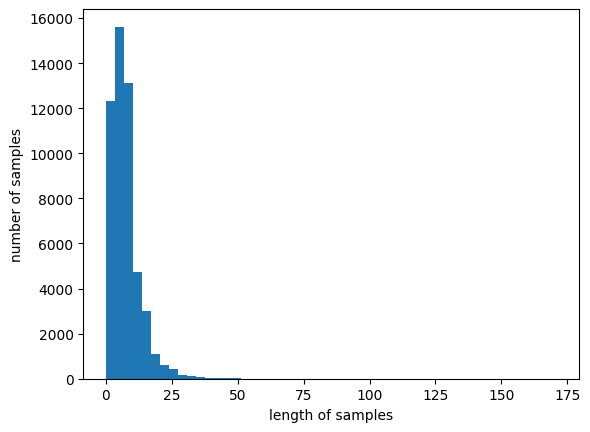

In [63]:
# 전체 데이터에서 가장 길이가 긴 리뷰와 전체 데이터의 길이 분포 확인
import matplotlib.pyplot as plt

print('리뷰의 최대 길이 :',max(len(review) for review in X))
print('리뷰의 평균 길이 :',sum(map(len, X))/len(X))
plt.hist([len(review) for review in X], bins=50)
plt.xlabel('length of samples')
plt.ylabel('number of samples')
plt.show()

In [64]:
# 몇 개의 샘플들을 온전히 보전할 수 있는지 확인
def below_threshold_len(max_len, nested_list):
  count = 0
  for sentence in nested_list:
    if(len(sentence) <= max_len):
        count = count + 1
  print('전체 샘플 중 길이가 %s 이하인 샘플의 비율: %s'%(max_len, (count / len(nested_list))*100))

max_len = 70
below_threshold_len(max_len, X)

전체 샘플 중 길이가 70 이하인 샘플의 비율: 99.98832775659481


In [65]:
X = pad_sequences(X, maxlen=max_len)

### BERT 이용해서 우선 라벨링하고 훈련해서 예측하는 방법으로 가보자

In [66]:
import torch
from transformers import BertTokenizer, BertForSequenceClassification
import torch.nn.functional as F

In [67]:
model_name = "kykim/bert-kor-base"
model = BertForSequenceClassification.from_pretrained(model_name, num_labels=2)
bertTokenizer = BertTokenizer.from_pretrained(model_name)

config.json:   0%|          | 0.00/725 [00:00<?, ?B/s]

pytorch_model.bin:   0%|          | 0.00/476M [00:00<?, ?B/s]

Some weights of BertForSequenceClassification were not initialized from the model checkpoint at kykim/bert-kor-base and are newly initialized: ['classifier.bias', 'classifier.weight']
You should probably TRAIN this model on a down-stream task to be able to use it for predictions and inference.


tokenizer_config.json:   0%|          | 0.00/80.0 [00:00<?, ?B/s]

vocab.txt:   0%|          | 0.00/344k [00:00<?, ?B/s]

In [76]:
bertTokenizer

BertTokenizer(name_or_path='kykim/bert-kor-base', vocab_size=42000, model_max_length=512, is_fast=False, padding_side='right', truncation_side='right', special_tokens={'unk_token': '[UNK]', 'sep_token': '[SEP]', 'pad_token': '[PAD]', 'cls_token': '[CLS]', 'mask_token': '[MASK]'}, clean_up_tokenization_spaces=True),  added_tokens_decoder={
	0: AddedToken("[PAD]", rstrip=False, lstrip=False, single_word=False, normalized=False, special=True),
	1: AddedToken("[UNK]", rstrip=False, lstrip=False, single_word=False, normalized=False, special=True),
	2: AddedToken("[CLS]", rstrip=False, lstrip=False, single_word=False, normalized=False, special=True),
	3: AddedToken("[SEP]", rstrip=False, lstrip=False, single_word=False, normalized=False, special=True),
	4: AddedToken("[MASK]", rstrip=False, lstrip=False, single_word=False, normalized=False, special=True),
}

In [68]:
def classify_emotion(text):
    # 텍스트 토큰화 및 패딩
    tokens = bertTokenizer(text, padding=True, truncation=True, return_tensors="pt")

    # 예측 수행
    with torch.no_grad():
        prediction = model(**tokens)

		# 예측 결과를 바탕으로 감정 출력
    prediction = F.softmax(prediction.logits, dim=1)
    output = prediction.argmax(dim=1).item()
    labels = [0, 1]

    return labels[output]

In [69]:
def pred_sentiment(text):
    output = classify_emotion(text)
    return output

In [70]:
from tqdm import tqdm
tqdm.pandas()

In [71]:
# 새로운 컬럼 만들기 - 예측
essence_review_prac1['pred_label'] = essence_review_prac1['cleaned_reviews'].progress_apply(pred_sentiment) # progress_apply(pred_sentiment) : tqdm에서 제공하는 함수. 과정을 보여준다.

essence_review_prac1.head(5)

100%|██████████| 51404/51404 [1:39:19<00:00,  8.63it/s]


,name,cleaned_reviews,tokenized_review,pred_label
0,[아랑Pick] VT 리들샷 100 에센스 50ml 기획/단품,얇고 민감한 제 피부엔 도 엄청 따갑고 자극적이게 느껴졌어요,"[얇다, 민감하다, 피부, 엔, 도, 엄청, 따갑다, 자극, 게, 느껴지다]",0
1,[아랑Pick] VT 리들샷 100 에센스 50ml 기획/단품,자주 사용하기엔 좀 그렇지만 가끔씩 써주면 좋은 제품 모델링팩 써준뒤에 사용하면 효...,"[자주, 가끔, 씩, 써주다, 좋다, 모델링, 팩, 써다, 뒤, 배]",0
2,[아랑Pick] VT 리들샷 100 에센스 50ml 기획/단품,모공에 효과가 좋아요,"[모공, 좋다]",0
3,[아랑Pick] VT 리들샷 100 에센스 50ml 기획/단품,재구매한거입니다,"[재다, 거, 이다]",0
4,[아랑Pick] VT 리들샷 100 에센스 50ml 기획/단품,아주 만족하면서 사용하고있어요,[만족하다],0


In [72]:
essence_review_prac1.pred_label.value_counts()

pred_label
0    48302
1     3102
Name: count, dtype: int64

In [74]:
essence_review_prac1[essence_review_prac1.pred_label == 1]

,name,cleaned_reviews,tokenized_review,pred_label
27,[아랑Pick] VT 리들샷 100 에센스 50ml 기획/단품,모공넓고 지성이고 트러블을 몇십년 달고살아요 피부과도 가보고 좋다는거 다 써봤는데 ...,"[모공, 넓다, 지성, 트러블, 십년, 달, 고, 살다, 피부, 과도, 가보다, 좋...",1
36,[아랑Pick] VT 리들샷 100 에센스 50ml 기획/단품,처음에 아플꺼라는 후기도 보고 친구가 리들샷 여러모로 좋다고해서 사용해보니 샷은 처...,"[아프다, 후기, 도, 보고, 리들샷, 여러, 모로, 좋다, 해보다, 샷, 은, 도...",1
60,[아랑Pick] VT 리들샷 100 에센스 50ml 기획/단품,저는 피부가 약한편이라 이걸 쓸때마다 하루 이상 자극이 느껴져서 못 쓰고있어요,"[는, 피부, 약, 걸, 쓸다, 자극, 느껴지다, 못, 쓰다]",1
103,[아랑Pick] VT 리들샷 100 에센스 50ml 기획/단품,이거 하고 나면 피부가 빤딱빤딱해지는 느낌 일 쓰고 하루 쉬고 해주고 있어요,"[거, 나다, 피부, 빨다, 빨다, 딱하다, 쓰다, 쉬, 고, 해주다]",1
125,[아랑Pick] VT 리들샷 100 에센스 50ml 기획/단품,피부가 뒤집어졌을때 사용하기 좋았어요,"[피부, 뒤집어지다, 좋다]",1
...,...,...,...,...
51358,라로슈포제 멜라B3 세럼 30ml,없이 보송한 느낌이고 피부결이 즉각적으로 매끄럽게 변하는게 느껴졌어요,"[없이, 보송하다, 피부, 결, 즉각, 매끄럽다, 변하다, 느껴지다]",1
51381,라로슈포제 멜라B3 세럼 30ml,한 번 맛 봐서 이제 다 쓰면 또 이 비싼 녀석 모셔올게요 피부타입 건성러 모공러 ...,"[맛, 다, 쓰다, 비싸다, 녀석, 모시다, 오다, 피부, 타입, 건성, 러, 공,...",1
51382,라로슈포제 멜라B3 세럼 30ml,괜히 샀다 이랬는데 지금 쓰니 좋아요,"[괜히, 사다, 이랬는데, 쓰다, 좋다]",1
51389,라로슈포제 멜라B3 세럼 30ml,색소침착이 있는 피부다보니 토닝과 병행해가며 관리중에 있습니다만 속에서 올라오는 속...,"[색소, 침착, 피부, 다, 토닝, 병행, 관리, 올라오다, 광, 은, 만족스럽다,...",1


In [73]:
y = essence_review_prac1['pred_label'].values

In [59]:
from sklearn.model_selection import train_test_split

X_train, y_train, X_test, y_test = train_test_split(X, y, test_size=0.25, random_state=42)
print('훈련용 리뷰의 개수 :', len(X_train))
print('테스트용 리뷰의 개수 :', len(X_test))

### 허깅페이스 이용해서 우선 라벨링하고 훈련해서 예측하는 방법으로 가보자

In [116]:
# 허깅페이스 모델 예제
from transformers import pipeline

# 텍스트 분류 모델을 사용하기
classifier = pipeline("text-classification", model="matthewburke/korean_sentiment")
# 긍정인지 부정인지 판단하기 위한 text
custom_tweet = "영화 재밌다."
preds = classifier(custom_tweet, return_all_scores=True)
is_positive = preds[0][1]['score'] > 0.5

# 긍정 여부 확인
print('긍정 :', is_positive)

config.json:   0%|          | 0.00/887 [00:00<?, ?B/s]

pytorch_model.bin:   0%|          | 0.00/498M [00:00<?, ?B/s]

tokenizer_config.json:   0%|          | 0.00/552 [00:00<?, ?B/s]

vocab.txt:   0%|          | 0.00/396k [00:00<?, ?B/s]

tokenizer.json:   0%|          | 0.00/788k [00:00<?, ?B/s]

special_tokens_map.json:   0%|          | 0.00/112 [00:00<?, ?B/s]

긍정 : True


In [119]:
# 함수로 만들어 보기
def pred_sentiment(text):
    # 문장 긍/부정 예측하기
    preds = classifier(text, return_all_scores=True)
    if preds[0][1]['score'] > 0.5:
        return 1
    else:
        return 0

In [120]:
from tqdm import tqdm
tqdm.pandas()

In [121]:
# 새로운 컬럼 만들기 - 예측
train_data['pred'] = train_data['cleaned_reviews'].progress_apply(pred_sentiment) # progress_apply(pred_sentiment) : tqdm에서 제공하는 함수. 과정을 보여준다.

train_data.head(5)

 18%|█▊        | 1766/10000 [04:21<20:21,  6.74it/s]


KeyboardInterrupt: 

In [ ]:
y_train = train_data['pred'].values

### BiLSTM
* essence_review_prac1 : Okt()로 분리

In [60]:
import re
from tensorflow.keras.layers import Embedding, Dense, LSTM, Bidirectional
from tensorflow.keras.models import Sequential
from tensorflow.keras.models import load_model
from tensorflow.keras.callbacks import EarlyStopping, ModelCheckpoint

embedding_dim = 100
hidden_units = 128

model = Sequential()
model.add(Embedding(vocab_size, embedding_dim))
model.add(Bidirectional(LSTM(hidden_units))) # Bidirectional LSTM을 사용
model.add(Dense(1, activation='sigmoid'))

es = EarlyStopping(monitor='val_loss', mode='min', verbose=1, patience=4)
mc = ModelCheckpoint('best_model.keras', monitor='val_acc', mode='max', verbose=1, save_best_only=True)

model.compile(optimizer='rmsprop', loss='binary_crossentropy', metrics=['acc'])
history = model.fit(X_train, y_train, epochs=15, callbacks=[es, mc], batch_size=256, validation_split=0.2)


Epoch 1/15
23/25 ━━━━━━━━━━━━━━━━━━━━ 0s 19ms/step - acc: 0.8370 - loss: 0.1861
Epoch 1: val_acc improved from -inf to 0.99875, saving model to best_model.keras
25/25 ━━━━━━━━━━━━━━━━━━━━ 8s 48ms/step - acc: 0.8510 - loss: 0.1718 - val_acc: 0.9987 - val_loss: 0.0096
Epoch 2/15
25/25 ━━━━━━━━━━━━━━━━━━━━ 0s 14ms/step - acc: 0.9977 - loss: 0.0165
Epoch 2: val_acc did not improve from 0.99875
25/25 ━━━━━━━━━━━━━━━━━━━━ 0s 17ms/step - acc: 0.9977 - loss: 0.0164 - val_acc: 0.9987 - val_loss: 0.0095
Epoch 3/15
25/25 ━━━━━━━━━━━━━━━━━━━━ 0s 14ms/step - acc: 0.9977 - loss: 0.0160
Epoch 3: val_acc did not improve from 0.99875
25/25 ━━━━━━━━━━━━━━━━━━━━ 0s 17ms/step - acc: 0.9978 - loss: 0.0159 - val_acc: 0.9987 - val_loss: 0.0095
Epoch 4/15
25/25 ━━━━━━━━━━━━━━━━━━━━ 0s 14ms/step - acc: 0.9985 - loss: 0.0112
Epoch 4: val_acc did not improve from 0.99875
25/25 ━━━━━━━━━━━━━━━━━━━━ 1s 18ms/step - acc: 0.9984 - loss: 0.0113 - val_acc: 0.9987 - val_loss: 0.0097
Epoch 5/15
25/25 ━━━━━━━━━━━━━━━━━━━━

In [61]:
loaded_model = load_model('best_model.keras')
print("테스트 정확도: %.4f" % (loaded_model.evaluate(X_test, y_test)[1]))


63/63 ━━━━━━━━━━━━━━━━━━━━ 1s 6ms/step - acc: 1.0000 - loss: 0.0017
테스트 정확도: 1.0000


처음 총 10000개의 데이터로 진행했을 때, 정확도가 100이 나온이유 : 긍정 리뷰가 너무 많다.

--> 그래서 그냥 전체 데이터에 대해서 실시함.

### KoBERT로 분류 예측